# 图表反演

In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

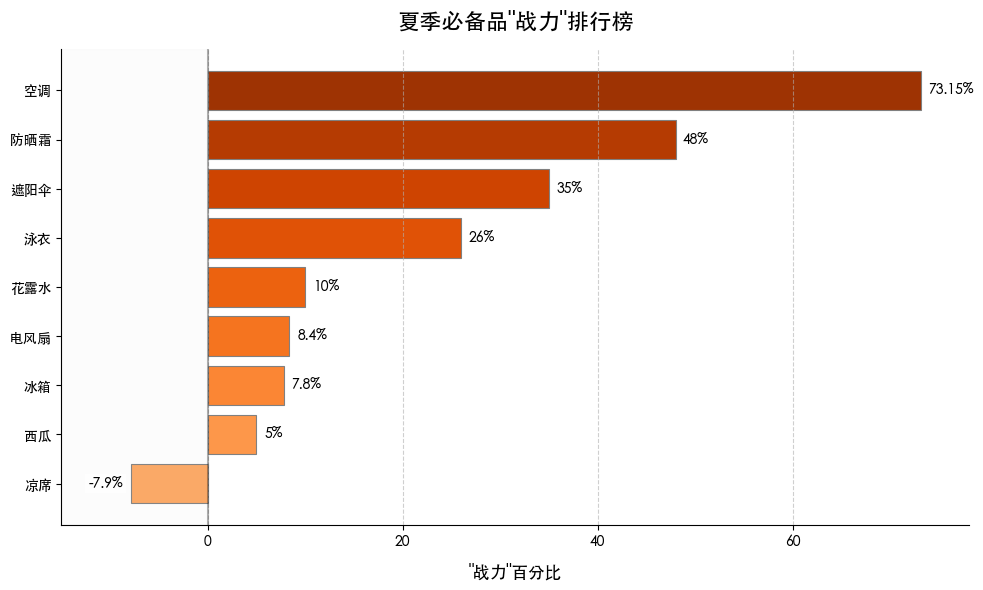

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 夏季必备品名称
labels = ['空调', '防晒霜', '遮阳伞', '泳衣', '花露水', '电风扇', '冰箱', '西瓜', '凉席']
# 对应的“战力”百分比数据
values = [73.15, 48, 35, 26, 10, 8.4, 7.8, 5, -7.9]

# 数据排序（升序，但绘图时会反转，实现值越大越靠上）
sorted_data = sorted(zip(values, labels), reverse=False)
values, labels = zip(*sorted_data)

# 创建画布
fig, ax = plt.subplots(figsize=(10, 6))

# 设置渐变色条（值越大颜色越深）
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(values)))

# 绘制美化后的横向条形图
bars = ax.barh(labels, values, color=colors, edgecolor='gray', linewidth=0.8)

# 设置X轴范围（重点修改：负向扩展到-15）
ax.set_xlim(-15, max(values) + 5)

# 添加背景网格线
ax.grid(axis='x', linestyle='--', alpha=0.6)

# 设置标题和标签
ax.set_title('夏季必备品"战力"排行榜', fontsize=16, pad=15)
ax.set_xlabel('"战力"百分比', fontsize=12, labelpad=10)

# 调整刻度和标签样式
ax.tick_params(axis='both', which='major', labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 优化数据标签位置（根据新的X轴范围调整）
for bar, value in zip(bars, values):
    # 正值标签位置微调，增加间距
    x_pos = value + 0.8 if value > 0 else value - 0.8
    # 负值标签位置随X轴范围调整
    ax.text(x_pos,
            bar.get_y() + bar.get_height()/2,
            f'{value}%',
            ha='left' if value > 0 else 'right',
            va='center',
            fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# 添加参考线（0值位置）
ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# 添加负向区域背景色（可选美化）
ax.axvspan(-15, 0, alpha=0.05, color='lightgray')

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()

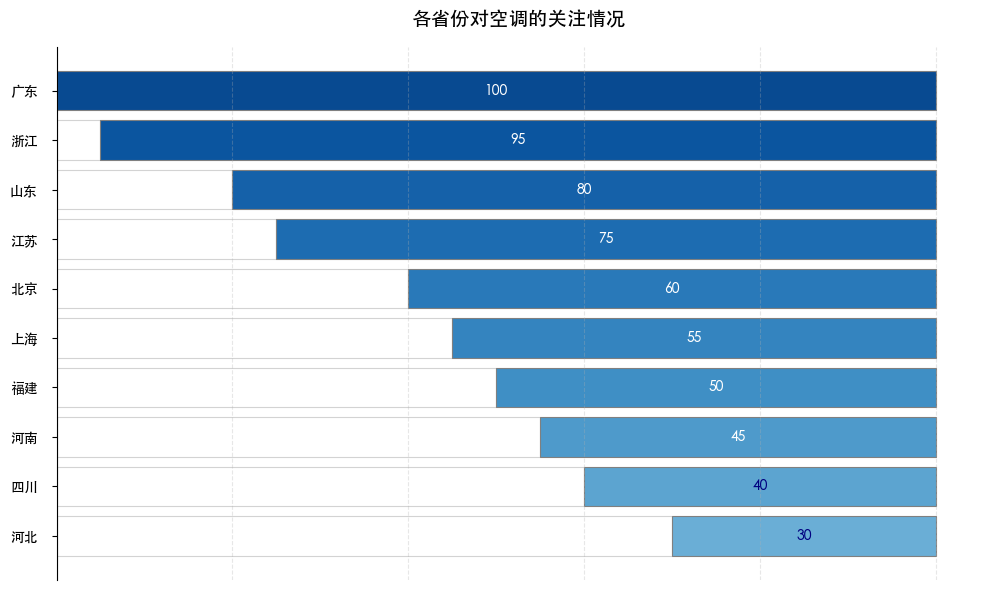

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 省份名称和模拟数据（可根据实际数据替换）
provinces = ['广东', '浙江', '山东', '江苏', '北京', '上海', '福建', '河南', '四川', '河北']
blue_percents = [100, 95, 80, 75, 60, 55, 50, 45, 40, 30]
white_percents = [100 - p for p in blue_percents]

# 数据排序（升序排列）
sorted_data = sorted(zip(blue_percents, white_percents, provinces))
blue_percents, white_percents, provinces = zip(*sorted_data)

# 创建画布
fig, ax = plt.subplots(figsize=(10, 6))

# 设置渐变色（从浅蓝到深蓝）
colors = plt.cm.Blues(np.linspace(0.5, 0.9, len(provinces)))

# 绘制美化后的横向堆叠条形图
bar_white = ax.barh(provinces, white_percents, color='white', edgecolor='lightgray', linewidth=0.8)
bar_blue = ax.barh(provinces, blue_percents, left=white_percents, color=colors, edgecolor='gray', linewidth=0.8)

# 添加数据标签
for i, (blue, white) in enumerate(zip(blue_percents, white_percents)):
    # 在蓝色区域中间添加百分比标签
    ax.text(white + blue/2, i, f'{blue}', ha='center', va='center', 
            color='white' if blue > 40 else 'navy', fontweight='bold')

# 设置标题和底部说明文字
ax.set_title('各省份对空调的关注情况', fontsize=14, pad=15)

# 设置网格线
ax.grid(axis='x', linestyle='--', alpha=0.3)

# 隐藏上、右、下坐标轴
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# 调整刻度和标签样式
ax.tick_params(axis='y', which='major', labelsize=10, pad=10)
ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# 添加左侧参考线
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.5)

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()

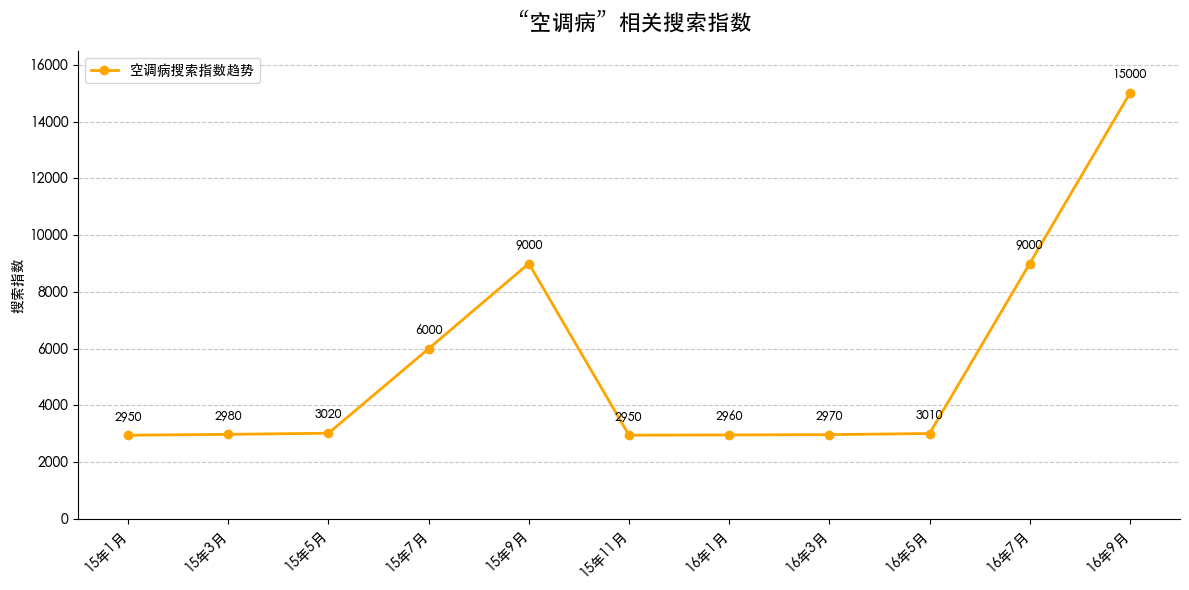

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 时间轴数据
dates = ['15年1月', '15年3月', '15年5月', '15年7月', '15年9月', 
         '15年11月', '16年1月', '16年3月', '16年5月', '16年7月', '16年9月']

# 添加了微小波动的搜索指数数据（手动调整）
search_index = [
    2950,  # 原3000
    2980,  # 原3000
    3020,  # 原3000
    6000,
    9000,
    2950,  # 原3000
    2960,  # 原3000
    2970,  # 原3000
    3010,  # 原3000
    9000,
    15000
]

# 将时间轴转为可用于绘图的索引
x = np.arange(len(dates))  

# 创建绘图对象
fig, ax = plt.subplots(figsize=(12, 6))

# 绘制折线图，设置线条宽度和标记样式
line, = ax.plot(x, search_index, color='orange', marker='o', markersize=6, 
                linewidth=2, label='空调病搜索指数趋势')

# 设置 x 轴刻度和标签
ax.set_xticks(x)
ax.set_xticklabels(dates, rotation=45, ha='right')

# 设置 y 轴范围和标签
ax.set_ylim(0, 1.1 * max(search_index))
ax.set_ylabel('搜索指数')

# 添加标题和副标题
ax.set_title('“空调病”相关搜索指数', fontsize=16, pad=15)

# 在折线上标注数值
for i, (xi, yi) in enumerate(zip(x, search_index)):
    ax.annotate(f'{int(round(yi))}',  # 取整显示
                (xi, yi),
                textcoords='offset points',
                xytext=(0, 10),  # 文本位置偏移
                ha='center',
                fontsize=9)

# 添加图例和网格线
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 隐藏上、右坐标轴
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()

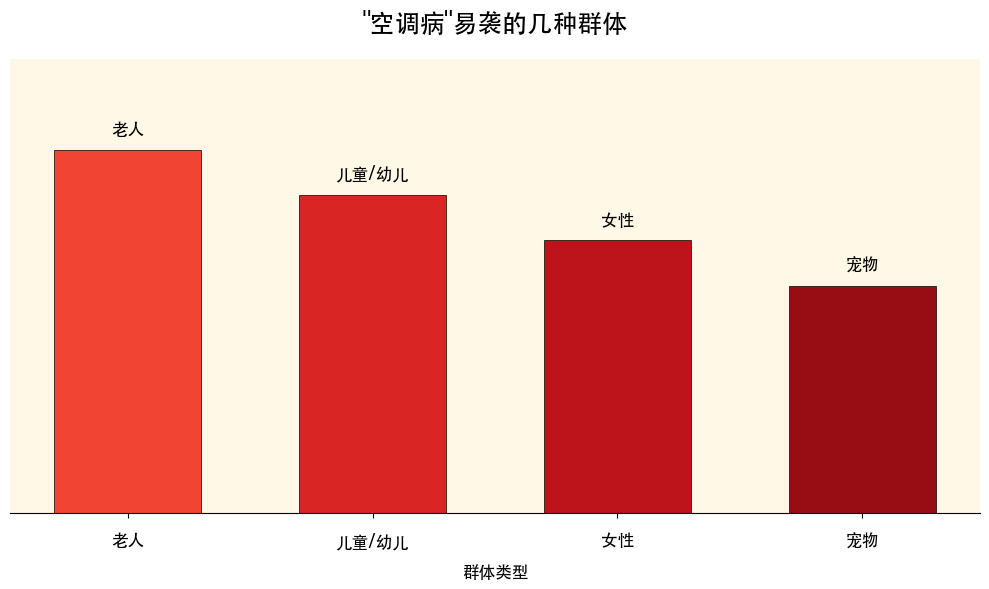

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
groups = ['老人', '儿童/幼儿', '女性', '宠物']
influence_level = [8, 7, 6, 5]

# 创建画布
fig, ax = plt.subplots(figsize=(10, 6))

# 设置背景色和网格
ax.set_facecolor('#FFF8E7')  # 温暖的浅橙色背景
ax.grid(axis='y', linestyle='--', alpha=0.3, color='gray')

# 绘制美化后的条形图
colors = plt.cm.Reds(np.linspace(0.6, 0.9, len(groups)))  # 渐变色
bars = ax.bar(groups, influence_level, color=colors, width=0.6, 
              edgecolor='black', linewidth=0.5)

# 添加标题和副标题
ax.set_title('"空调病"易袭的几种群体', fontsize=18, pad=20, fontweight='bold')

# 调整坐标轴
ax.set_ylim(0, 10)  # 固定y轴范围，使比较更直观
ax.set_yticks([])  # 隐藏y轴刻度
ax.set_xlabel('群体类型', fontsize=12, labelpad=10)

# 美化x轴标签
ax.tick_params(axis='x', which='major', labelsize=12, pad=10)

# 隐藏上、右、左坐标轴
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# 在每个条形上方添加简短描述
for bar, group in zip(bars, groups):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'{group}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()

“中暑”搜索指数是空调病的2倍以上可见中暑危害甚于空调病

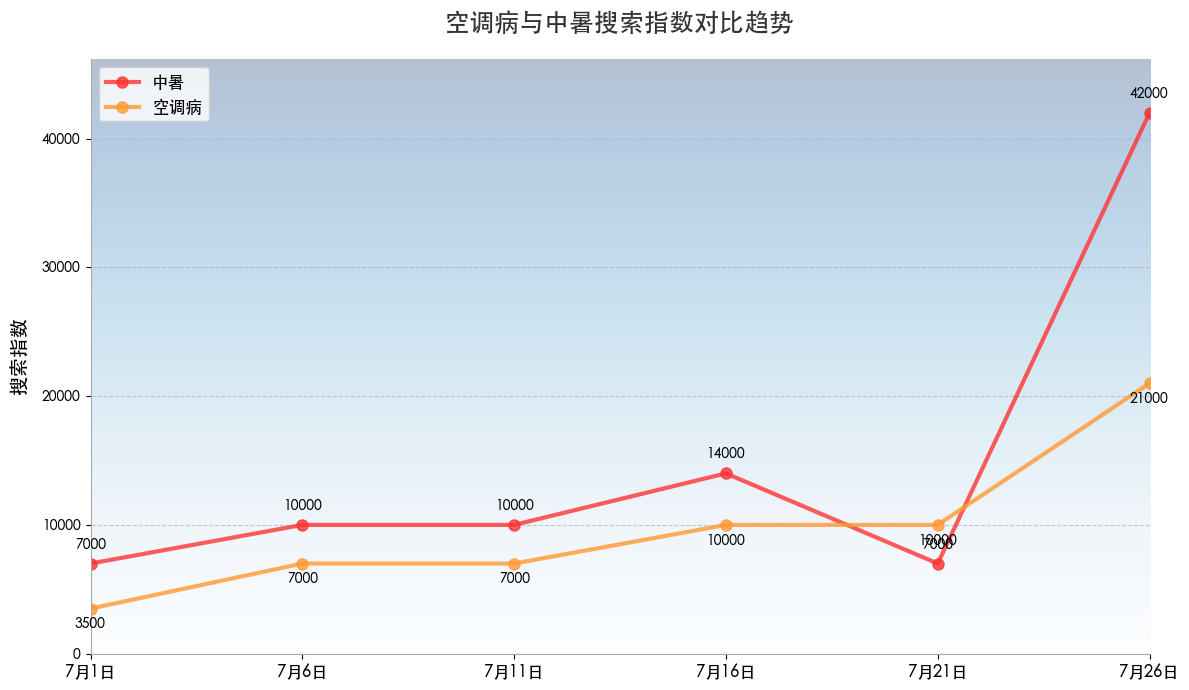

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 日期数据（修正重复年份问题）
dates = ['7月1日', '7月6日', '7月11日', '7月16日', '7月21日', '7月26日']
# 搜索指数数据
heatstroke_index = [7000, 10000, 10000, 14000, 7000, 42000]
air_condition_illness_index = [3500, 7000, 7000, 10000, 10000, 21000]

# 将日期转为可用于绘图的索引
x = np.arange(len(dates))  

# 创建绘图对象
fig, ax = plt.subplots(figsize=(12, 7))

# 设置渐变色背景（从浅蓝到深蓝）
gradient = np.linspace(0.95, 0.85, 256).reshape(256, 1)
ax.imshow(gradient, aspect='auto', extent=[0, len(dates)-1, 0, max(heatstroke_index)*1.1], 
          alpha=0.3, cmap=plt.cm.Blues)

# 绘制优化后的折线图
ax.plot(x, heatstroke_index, color='#FF3333', marker='o', markersize=8, 
        label='中暑', linewidth=3, alpha=0.8)
ax.plot(x, air_condition_illness_index, color='#FF9933', marker='o', markersize=8, 
        label='空调病', linewidth=3, alpha=0.8)

# 设置x轴和y轴
ax.set_xticks(x)
ax.set_xticklabels(dates, fontsize=12)
ax.set_ylabel('搜索指数', fontsize=14, labelpad=10)
ax.set_ylim(0, max(heatstroke_index) * 1.1)  # 留出顶部空间

# 设置美化后的标题
ax.set_title('空调病与中暑搜索指数对比趋势', 
             fontsize=18, fontweight='bold', pad=20, color='#333333')

# 添加数据标签
for i, (xi, yi) in enumerate(zip(x, heatstroke_index)):
    ax.annotate(f'{yi}', (xi, yi), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
    
for i, (xi, yi) in enumerate(zip(x, air_condition_illness_index)):
    ax.annotate(f'{yi}', (xi, yi), textcoords='offset points',
                xytext=(0, -15), ha='center', fontsize=10, fontweight='bold')

# 添加网格线
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 设置图例和边框
ax.legend(fontsize=12, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#AAAAAA')
ax.spines['bottom'].set_color('#AAAAAA')

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()